# Day 2 — DBSCAN & Hierarchical Clustering

## Objectives

- Explain the limitations of K-Means and when another clustering method may be preferred.
- Apply DBSCAN and interpret clusters and noise points.
- Build and interpret a hierarchical clustering dendrogram.
- Compare K-Means, DBSCAN, and hierarchical clustering.
- Determine which clustering method best fits the dataset.

## 1. Why K-Means Isn't Always Enough

K-Means is useful for discovering clusters, but it has several limitations.

- The number of clusters (`k`) must be selected in advance.
- It works best when clusters are relatively round and similarly sized.
- Every observation is assigned to a cluster, even potential outliers.

When the data contains irregularly shaped clusters or noise, other
clustering methods such as DBSCAN may be more appropriate.

## 2. DBSCAN

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise.

Instead of requiring the number of clusters in advance, DBSCAN identifies
clusters based on the density of observations.

It can also identify observations in sparse regions as noise.

The two main parameters are:

- `eps`: the maximum distance between two observations for them to be
  considered neighbors.
- `min_samples`: the minimum number of neighboring observations required
  to form a dense region.

DBSCAN labels noise points with `-1`.

In [1]:
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 3. Applying DBSCAN

DBSCAN does not require us to specify the number of clusters.

We will start with the parameters provided in the lesson:

- `eps = 0.5`
- `min_samples = 5`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
df = pd.read_csv(
    r"D:\Desktop\AI & ML BinX Tech\Python\Week 1\tested.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = df[features].copy()

X.isnull().sum()

Pclass     0
Age       86
SibSp      0
Parch      0
Fare       1
dtype: int64

In [6]:
X = X.fillna(X.median())

X.isnull().sum()

Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.87348191,  0.38623105, -0.49947002, -0.4002477 , -0.49741333],
       [ 0.87348191,  1.37137004,  0.61699237, -0.4002477 , -0.51227801],
       [-0.31581919,  2.55353683, -0.49947002, -0.4002477 , -0.46410047],
       [ 0.87348191, -0.20485235, -0.49947002, -0.4002477 , -0.48247516],
       [ 0.87348191, -0.59890794,  0.61699237,  0.61989583, -0.4174915 ]])

In [8]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_labels[:20]

array([ 0, -1, -1,  0,  1,  0,  0, -1,  0,  2,  0,  3,  8, -1,  7,  4,  5,
        0,  6,  0])

In [9]:
unique_labels = np.unique(dbscan_labels)

unique_labels

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9])

In [10]:
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(dbscan_labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 10
Number of noise points: 126


## DBSCAN Results

Using `eps = 0.5` and `min_samples = 5`, DBSCAN identified 10 clusters
and 126 noise points.

The noise points are observations that did not belong to sufficiently
dense regions. Unlike K-Means, DBSCAN can explicitly identify these
observations instead of assigning every point to a cluster.

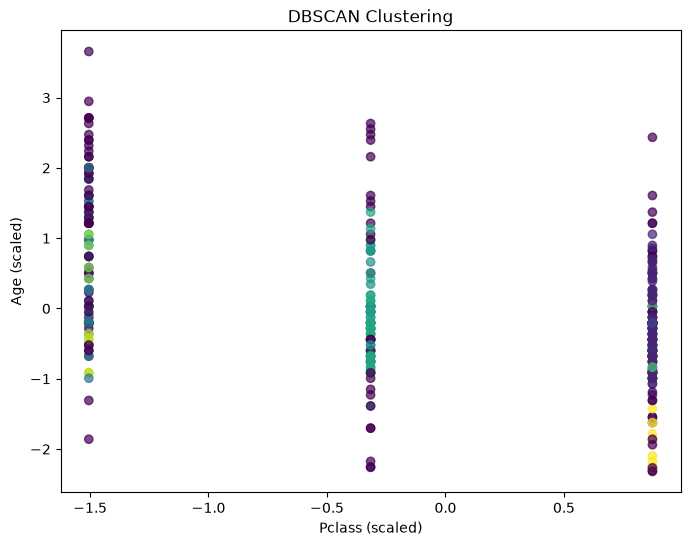

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    alpha=0.7
)

plt.xlabel(f"{features[0]} (scaled)")
plt.ylabel(f"{features[1]} (scaled)")
plt.title("DBSCAN Clustering")

plt.show()

## 4. Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters by repeatedly
merging the closest groups of observations.

A dendrogram is used to visualize this process. By selecting a cut
height on the dendrogram, we can determine the resulting number of
clusters.

In [12]:
Z = linkage(
    X_scaled,
    method="ward"
)

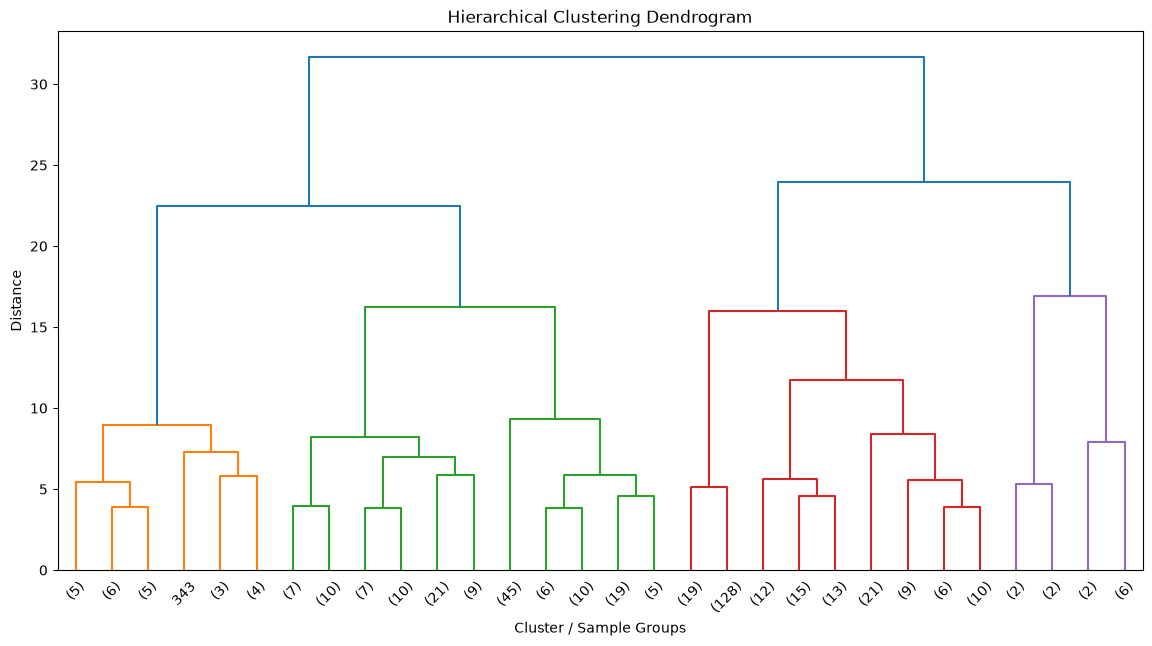

In [13]:
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.xlabel("Cluster / Sample Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [14]:
cut_height = 20

hierarchical_labels = fcluster(
    Z,
    t=cut_height,
    criterion="distance"
)

n_hierarchical_clusters = len(np.unique(hierarchical_labels))

print("Cut height:", cut_height)
print("Number of hierarchical clusters:", n_hierarchical_clusters)

Cut height: 20
Number of hierarchical clusters: 4


### Hierarchical Clustering Results

Using a cut height of `20`, hierarchical clustering produced
4 clusters.

The cut height was selected based on the larger gaps visible in the
dendrogram before the major cluster merges. This allows the data to be
divided into distinct groups while preserving the hierarchical structure.

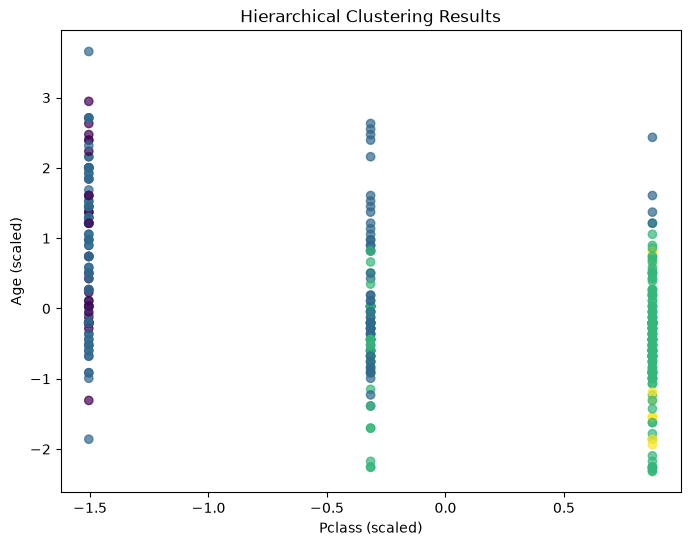

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=hierarchical_labels,
    alpha=0.7
)

plt.xlabel(f"{features[0]} (scaled)")
plt.ylabel(f"{features[1]} (scaled)")
plt.title("Hierarchical Clustering Results")

plt.show()

### Hierarchical Clustering Visualization

The visualization shows the clusters produced by hierarchical clustering
using `Pclass` and `Age` as the two displayed features.

Using a cut height of `20`, the algorithm divided the dataset into
4 clusters. The different colors represent the cluster assignments.

## 5. Comparing Clustering Methods

This section compares the three clustering methods used on the same
Titanic dataset.

| Method | Result | Strength | Limitation |
|---|---|---|---|
| K-Means | 3 clusters | Simple and efficient | Requires choosing the number of clusters in advance |
| DBSCAN | 10 clusters and 126 noise points | Detects noise and does not require a predefined number of clusters | Sensitive to `eps` and `min_samples` |
| Hierarchical Clustering | 4 clusters | Shows the hierarchical structure of the data using a dendrogram | Can be slower on large datasets |

### Interpretation

K-Means grouped all observations into 3 clusters and required the number
of clusters to be selected in advance.

DBSCAN identified 10 clusters and detected 126 observations as noise.
This shows its ability to identify points that do not belong to dense
regions.

Hierarchical clustering produced 4 clusters using a cut height of 20.
The dendrogram provided a visual representation of how observations were
progressively merged into larger groups.

## 6. Final Conclusion

The three clustering methods produced different results because they use
different approaches to identify structure in the data.

K-Means is useful when the approximate number of clusters is known and
the data is expected to contain relatively compact groups.

DBSCAN is useful when detecting noise or outliers is important. In this
dataset, DBSCAN identified 126 noise points and discovered 10 clusters
without requiring the number of clusters to be specified beforehand.

Hierarchical clustering provided a different perspective by showing the
nested structure of the data through a dendrogram. Using a cut height of
20 resulted in 4 clusters.

For this dataset, hierarchical clustering and K-Means provide a clearer
high-level grouping of the observations, while DBSCAN is particularly
useful for identifying potential noise points and outliers.

Overall, the choice of clustering method depends on the structure of the
data and the goal of the analysis.